In [2]:
from Bio import SeqIO 
import requests

url = "https://www.uniprot.org/uniprot/P04156.fasta" 
response = requests.get(url) 

import io

record = SeqIO.read(io.StringIO(response.text), "fasta")

print(f"Protein: {record.description}")
print(f"Length: {len(record.seq)} amino acids")
print(f"Sequence: {record.seq}")

Protein: sp|P04156|PRIO_HUMAN Major prion protein OS=Homo sapiens OX=9606 GN=PRNP PE=1 SV=1
Length: 253 amino acids
Sequence: MANLGCWMLVLFVATWSDLGLCKKRPKPGGWNTGGSRYPGQGSPGGNRYPPQGGGGWGQPHGGGWGQPHGGGWGQPHGGGWGQPHGGGWGQGGGTHSQWNKPSKPKTNMKHMAGAAAAGAVVGGLGGYMLGSAMSRPIIHFGSDYEDRYYRENMHRYPNQVYYRPMDEYSNQNNFVHDCVNITIKQHTVTTTTKGENFTETDVKMMERVVEQMCITQYERESQAYYQRGSSMVLFSSPPVILLISFLIFLIVG


In [7]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

analysis = ProteinAnalysis(str(record.seq))

composition = analysis.amino_acids_percent

for amino_acid, percentage in sorted(composition.items()):
    print(f"{amino_acid}: {percentage:.2f}%")

A: 3.95%
C: 1.58%
D: 2.37%
E: 3.56%
F: 2.77%
G: 17.79%
H: 3.95%
I: 3.56%
K: 3.95%
L: 4.74%
M: 4.74%
N: 4.74%
P: 6.72%
Q: 5.93%
R: 4.35%
S: 5.93%
T: 5.14%
V: 5.53%
W: 3.56%
Y: 5.14%


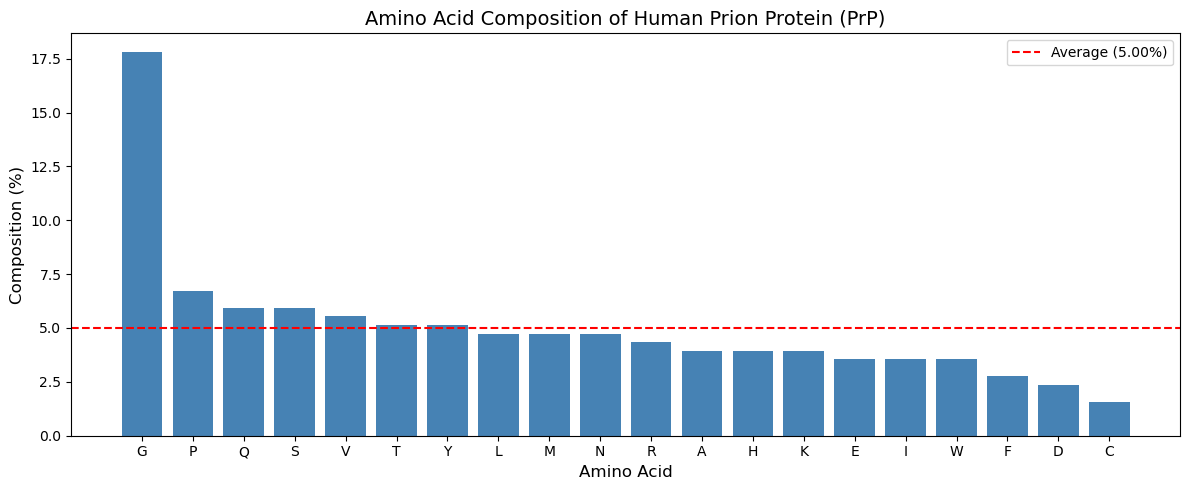

In [8]:
import matplotlib.pyplot as plt
sorted_composition = sorted(composition.items(), key=lambda x: x[1], reverse=True)

amino_acids = [pair[0] for pair in sorted_composition]
percentages = [pair[1] for pair in sorted_composition]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(amino_acids, percentages, color="steelblue")

ax.set_title("Amino Acid Composition of Human Prion Protein (PrP)", fontsize=14)
ax.set_xlabel("Amino Acid", fontsize=12)
ax.set_ylabel("Composition (%)", fontsize=12)

average = sum(percentages) / len(percentages)
ax.axhline(y=average, color="red", linestyle="--", label=f"Average ({average:.2f}%)")
ax.legend()

plt.tight_layout()
plt.show()